# 02 — Khám phá dữ liệu VietSuperSpeech (EDA): xem, nghe, thống kê

Mục tiêu: hiểu rõ hơn về các bản ghi thật trong VietSuperSpeech — bao
nhiêu mẫu, độ dài ra sao, **nhìn được** (waveform + spectrogram), **nghe
được** (audio player), và **biểu đồ** tổng hợp.

**Lưu ý cấu trúc dataset quan trọng**:
cột `audio` trong VietSuperSpeech chỉ là **chuỗi đường dẫn tương đối**
(vd. `audio/asr_segments_vietcetera_part00/..._seg047.wav`), KHÔNG phải
kiểu `Audio` của thư viện `datasets` tự động giải mã — nên `item["audio"]`
sẽ ra một **string**, không phải dict `{"array":..., "sampling_rate":...}`.
Phải tự tải file bằng `hf_hub_download` rồi đọc bằng `soundfile`. Notebook
này xử lý sẵn việc đó.

Xem thêm phát hiện về số liệu dataset (khác đề cương):
`docs/notes/dataset_discrepancy.md`.

## 0. Cài thư viện (bỏ qua nếu đã có sẵn — vd. chạy local đã cài qua requirements.txt)

In [1]:
!pip install -q datasets huggingface_hub soundfile librosa matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import itertools
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import soundfile as sf
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from IPython.display import Audio, display

HF_DATASET_ID = "thanhnew2001/VietSuperSpeech"
AUDIO_CACHE_DIR = "data/raw/eda_audio_cache"  # tải về đây để nghe lại nhiều lần không cần tải lại
Path(AUDIO_CACHE_DIR).mkdir(parents=True, exist_ok=True)
SEED = 42


def fetch_audio(relative_path: str) -> tuple[np.ndarray, int]:
    """Tải 1 file audio (đường dẫn tương đối trong repo dataset) về cache local, đọc bằng soundfile."""
    local_path = hf_hub_download(
        HF_DATASET_ID, relative_path, repo_type="dataset", local_dir=AUDIO_CACHE_DIR
    )
    data, sr = sf.read(local_path)
    return data, sr

## 1. Thống kê tổng thể (toàn bộ tập, không tải audio)

Dùng lại kết quả từ `src/data/survey.py` nếu đã có sẵn
(`reports/results/dataset_survey_*.json`) — vì duyệt toàn bộ 60K+/6K+ mẫu
để lấy thống kê chính xác mất vài phút, không cần chạy lại mỗi lần mở
notebook này. Nếu chưa có (vd. chạy lần đầu trên Kaggle), notebook tự tính.

In [2]:
def load_or_compute_stats(split: str) -> dict:
    path = Path(f"reports/results/dataset_survey_{split}.json")
    if path.exists():
        print(f"Dùng lại {path}")
        with open(path, encoding="utf-8") as f:
            return json.load(f)

    print(f"Chưa có sẵn — tự khảo sát tập {split} (không tải audio, chỉ đọc text/duration)...")
    from collections import Counter

    ds = load_dataset(HF_DATASET_ID, split=split, streaming=True)
    n, total_dur, durations, source_counts = 0, 0.0, [], Counter()
    for item in ds:
        n += 1
        total_dur += item["duration"]
        durations.append(item["duration"])
        source_counts[item["source"]] += 1
    durations.sort()
    return {
        "split": split,
        "n_samples": n,
        "total_duration_hours": total_dur / 3600,
        "duration_min_s": durations[0],
        "duration_max_s": durations[-1],
        "duration_mean_s": total_dur / n,
        "top_10_sources_by_count": source_counts.most_common(10),
        "_durations_raw": durations,  # chỉ có khi tự tính, dùng để vẽ histogram
    }


train_stats = load_or_compute_stats("train")
val_stats = load_or_compute_stats("validation")

for s in (train_stats, val_stats):
    print(f"\n=== {s['split']} ===")
    print(f"  Số mẫu: {s['n_samples']:,}")
    print(f"  Tổng thời lượng: {s['total_duration_hours']:.2f} giờ")
    print(f"  Độ dài: min={s['duration_min_s']}s, max={s['duration_max_s']}s, mean={s['duration_mean_s']:.2f}s")

Chưa có sẵn — tự khảo sát tập train (không tải audio, chỉ đọc text/duration)...


Repo card metadata block was not found. Setting CardData to empty.


Chưa có sẵn — tự khảo sát tập validation (không tải audio, chỉ đọc text/duration)...


Repo card metadata block was not found. Setting CardData to empty.



=== train ===
  Số mẫu: 60,656
  Tổng thời lượng: 220.84 giờ
  Độ dài: min=10.0s, max=15.0s, mean=13.11s

=== validation ===
  Số mẫu: 6,749
  Tổng thời lượng: 24.57 giờ
  Độ dài: min=10.0s, max=15.0s, mean=13.11s


## 2. Biểu đồ tổng hợp

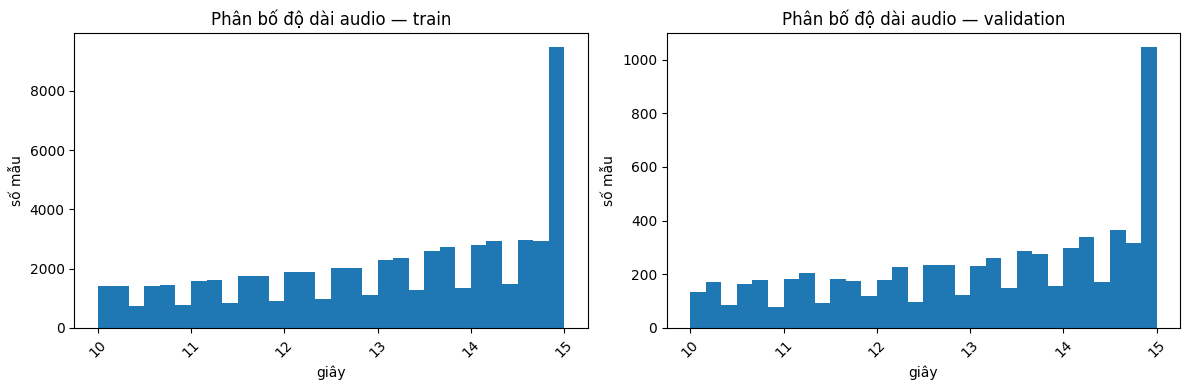

Lưu ý: dữ liệu thật gần như đồng nhất 10-15 giây — xem docs/notes/dataset_discrepancy.md.


In [3]:
# 2a. Phân bố độ dài audio (bucket có sẵn từ survey, hoặc tự tính từ _durations_raw)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, stats in zip(axes, (train_stats, val_stats)):
    if "duration_buckets" in stats:
        buckets = stats["duration_buckets"]
        ax.bar(list(buckets.keys()), list(buckets.values()))
    elif "_durations_raw" in stats:
        ax.hist(stats["_durations_raw"], bins=30)
    ax.set_title(f"Phân bố độ dài audio — {stats['split']}")
    ax.set_xlabel("giây")
    ax.set_ylabel("số mẫu")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
print("Lưu ý: dữ liệu thật gần như đồng nhất 10-15 giây — xem docs/notes/dataset_discrepancy.md.")

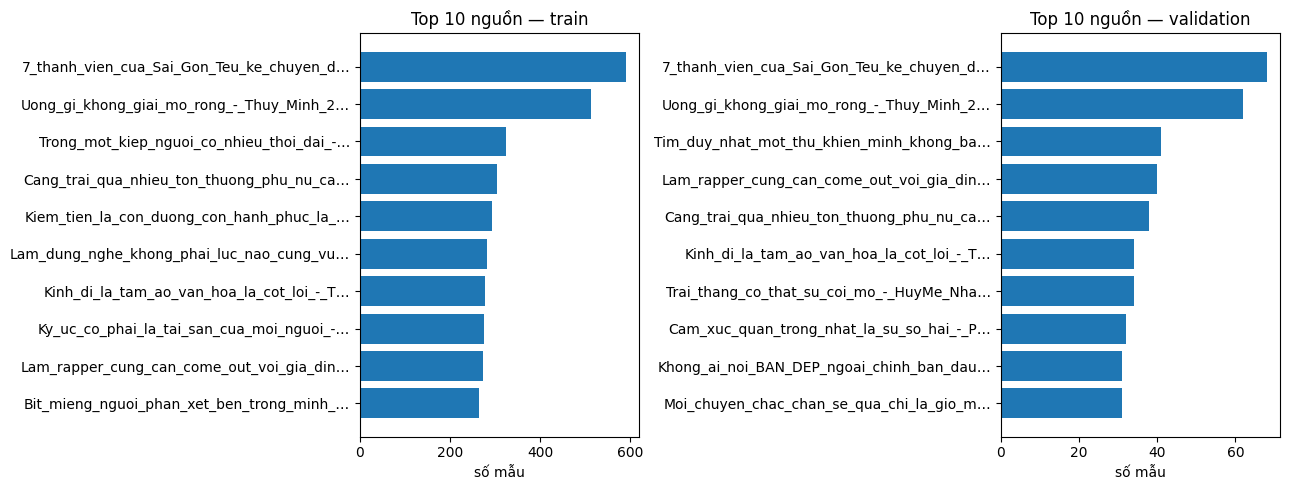

In [4]:
# 2b. Top nguồn (kênh video) theo số lượng mẫu
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, stats in zip(axes, (train_stats, val_stats)):
    names = [n[:40] + ("…" if len(n) > 40 else "") for n, _ in stats["top_10_sources_by_count"]]
    counts = [c for _, c in stats["top_10_sources_by_count"]]
    ax.barh(names[::-1], counts[::-1])
    ax.set_title(f"Top 10 nguồn — {stats['split']}")
    ax.set_xlabel("số mẫu")
plt.tight_layout()
plt.show()

In [5]:
# 2c. Độ dài transcript (ký tự) — nếu có trong file thống kê đã lưu sẵn
if "text_char_len_mean" in train_stats:
    print(f"Độ dài transcript trung bình (train): {train_stats['text_char_len_mean']:.1f} ký tự, "
          f"{train_stats['text_word_len_mean']:.1f} từ")
    print(f"Số ký tự khác nhau (bảng chữ cái + khoảng trắng): {train_stats['n_unique_chars']}")

## 3. Lấy mẫu ngẫu nhiên để xem & nghe

Dùng `dataset.shuffle(seed=..., buffer_size=...)` trên stream — xáo trộn
gần-đúng (approximate shuffle) trong một buffer, nhanh hơn nhiều so với
duyệt toàn bộ 60K+ mẫu, nhưng vẫn đa dạng hơn nhiều so với việc chỉ lấy
N mẫu đầu tiên (vốn dồn vào rất ít kênh nguồn).

In [6]:
N_SAMPLES = 10

ds_shuffled = load_dataset(HF_DATASET_ID, split="train", streaming=True).shuffle(seed=SEED, buffer_size=5000)
samples = list(itertools.islice(ds_shuffled, N_SAMPLES))
print(f"Đã chọn {len(samples)} mẫu ngẫu nhiên (seed={SEED}).")

Repo card metadata block was not found. Setting CardData to empty.


Đã chọn 10 mẫu ngẫu nhiên (seed=42).


## 4. Nhìn (waveform + spectrogram) và nghe từng mẫu


Mẫu 1/10
Nguồn:      Ai_giuc_de_thi_gop_tien_nuoi_con_ho_voi_-_Lam_Thuy_Nhan_Me_cua_He_va_Hiu_Coi_Mo_SS3_Ep19.mp4
Thời lượng: 10.70s (báo cáo)
Transcript: ĐÓ NHƯNG MÀ NHIỀU NGƯỜI LÀ KÊU LÀ TẠI VÌ NGƯỜI TA KHÔNG HIỂU NHỮNG CÁI LÝ DO ĐÓ NGƯỜI TA HAY NGƯỜI NGOÀI NGƯỜI TA KHÔNG NGƯỜI TA CŨNG KHÔNG CÓ TÌM HIỂU NHIỀU VẤN ĐỀ NỮA LÀ NGƯỜI TA CHỈ MUỐN TIN NHỮNG GÌ NGƯỜI TA MUỐN TIN THÔI ĐÚNG RỒI


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


(…)cua_He_va_Hiu_Coi_Mo_SS3_Ep19_seg158.wav:   0%|          | 0.00/342k [00:00<?, ?B/s]

Thời lượng thực tế: 10.70s, sample rate: 16000 Hz


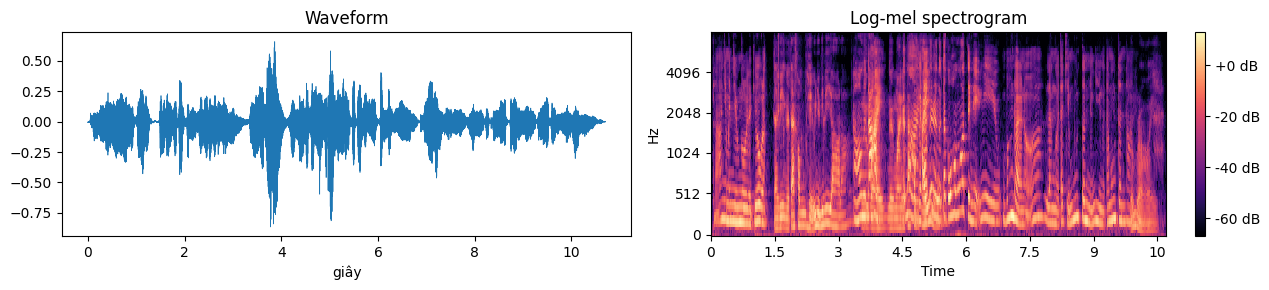


Mẫu 2/10
Nguồn:      Moi_nguoi_can_chon_san_cua_rieng_minh_de_da_-_HURRYKNG_HaveASip_225.mp4
Thời lượng: 14.50s (báo cáo)
Transcript: COPO KIỂU BAN ĐẦU THÌ EM KHÔNG THÍCH LẮM KIỂU NÓ CHỈ LÀ NƯỚC VỚI LẠI CÀ PHÊ TẠI SAO BÁNH ỐNG CÀ PHÊ SỮA NÈ CÀ PHÊ SỮA NÀY NỌ THÌ


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


(…)de_da_-_HURRYKNG_HaveASip_225_seg014.wav:   0%|          | 0.00/464k [00:00<?, ?B/s]

Thời lượng thực tế: 14.50s, sample rate: 16000 Hz


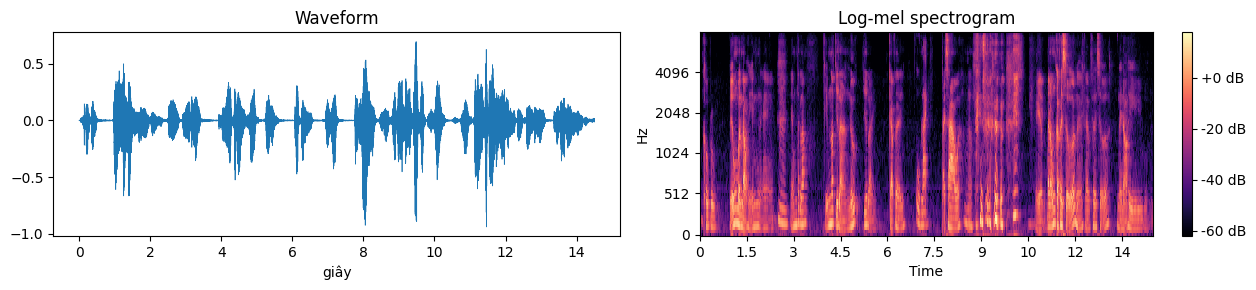


Mẫu 3/10
Nguồn:      Lam_viec_tu_xa_qua_goc_nhin_nhan_su_-_Abhishek_Mathur_VP_of_HR_VNG_Corporation_VI_S2_EP21.mp4
Thời lượng: 13.60s (báo cáo)
Transcript: OF IN THE SATI TOWART LE COMMENT WORK FOR A STARTUP IN INDOS CONTRICE IT THING THE BEAVE AND A GOOD AND PROPERS ANTION OF DINH


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


(…)HR_VNG_Corporation_VI_S2_EP21_seg016.wav:   0%|          | 0.00/435k [00:00<?, ?B/s]

Thời lượng thực tế: 13.60s, sample rate: 16000 Hz


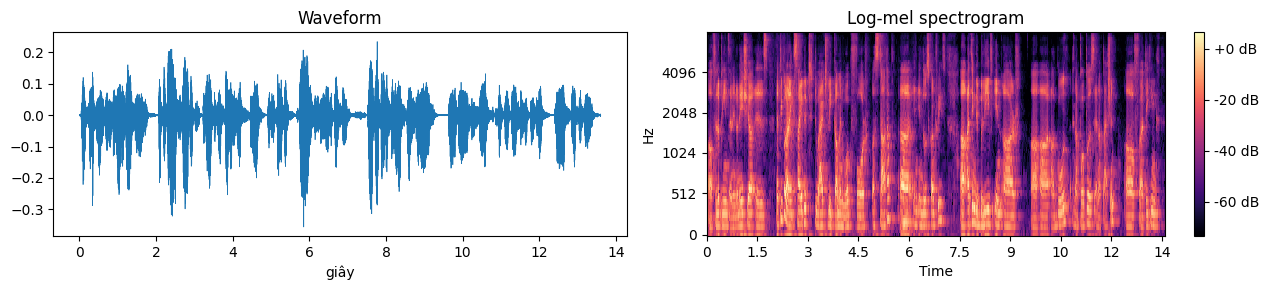


Mẫu 4/10
Nguồn:      Kham_pha_nhung_insight_dat_gia_o_nhieu_nganh_hang_tu_2_research_guru_Young_Marketers_EP05.mp4
Thời lượng: 13.60s (báo cáo)
Transcript: CHO MỘT CÁI ĐỐI TƯỢNG RẤT LÀ BÌNH DÂN VÀ RẤT LÀ GỌI LÀ CÒN KHÓ KHĂN MÀ TỰ NHIÊN CÁI VAI TRÒ CỦA FREN NÓ CŨNG ĐƯỢC TĂNG LÊN RẤT LÀ NHIỀU LÀ MỘT CÁI PREM MANG LẠI KHÔNG CHỈ CÁI NÀY MÀ CẢ NIỀM VUI CẢ CÁI SỰ THẤU CẢM KHÔNG CHỈ LÀ CHO


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


(…)rch_guru_Young_Marketers_EP05_seg214.wav:   0%|          | 0.00/435k [00:00<?, ?B/s]

Thời lượng thực tế: 13.60s, sample rate: 16000 Hz


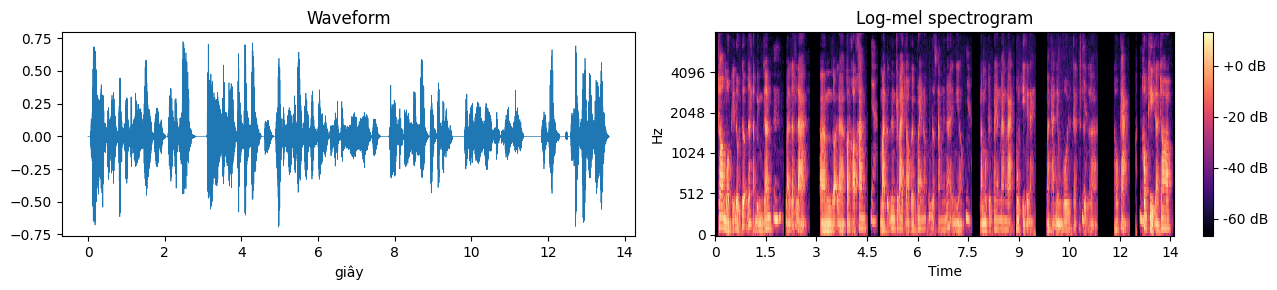


Mẫu 5/10
Nguồn:      Khach_san_phat_trien_nhu_the_nao_thoi_40_-_Niklas_Wagner_General_Manager_New_World_Saigon_Hotel.mp4
Thời lượng: 14.00s (báo cáo)
Transcript: NOTHER THE PRESENT THE JOB ASAN AND TOUR PASTEIN TOP SO SHOT AKG PROMOTION AND AND THE BEING GATES DO LOGIT THY


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


(…)anager_New_World_Saigon_Hotel_seg099.wav:   0%|          | 0.00/448k [00:00<?, ?B/s]

Thời lượng thực tế: 14.00s, sample rate: 16000 Hz


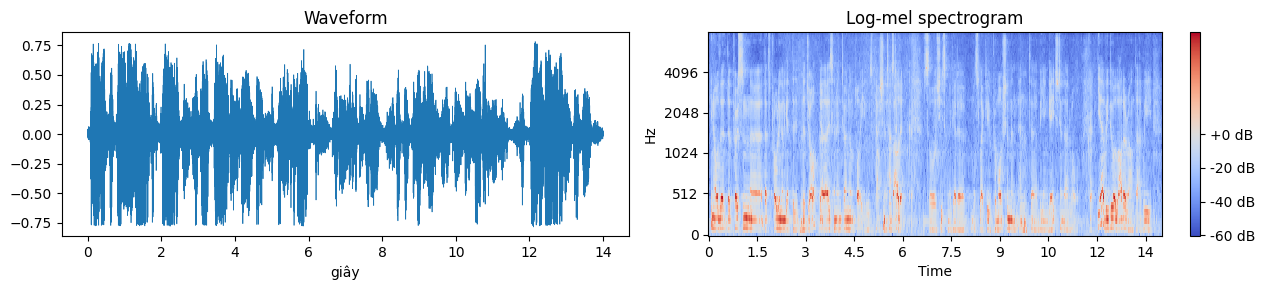


Mẫu 6/10
Nguồn:      13_tua_sach_va_hon_13_bai_hoc_duoc_mang_len_hoang_dao_HaveASip_Highlight.mp4
Thời lượng: 10.60s (báo cáo)
Transcript: TẠI VÌ DƯƠNG NGHĨ LÀ NẾU NHƯ MÀ CÓ MỘT CÁI SỰ CỐ XẢY RA TRONG MỘT CÁI MỘT CÁI EVENT XẢY RA LÀ DƯƠNG LÊN HOANG ĐẢO THÌ NÓ LÀ MỘT CÁI VIỆC MÀ NÓ PHẢI XẢY RA


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


(…)_hoang_dao_HaveASip_Highlight_seg003.wav:   0%|          | 0.00/339k [00:00<?, ?B/s]

Thời lượng thực tế: 10.60s, sample rate: 16000 Hz


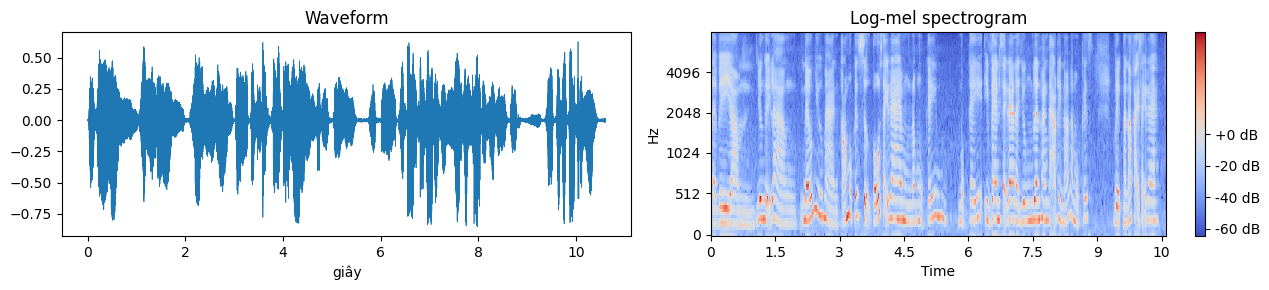


Mẫu 7/10
Nguồn:      Ai_giat_day_nhung_con_roi_tlinh_-_Rapper_tlinh_HaveASip_120.mp4
Thời lượng: 13.80s (báo cáo)
Transcript: THÌ MÌNH PHẢI THẾ CHỨ MÌNH PHẢI CÓ MỘT CÁI CÓ MỘT CÁI SỰ LÀ MÌNH PHẢI TIN VÀO TIN VÀO CÁI GÓC NHÌN MÌNH ĐẾN CÙNG ẤY EM NGHĨ THẾ TỨC LÀ ĐƯƠNG NHIÊN MÌNH SẼ CÓ NHỮNG CÁI CÓ NHỮNG CÁI KIỂU XẢY RA LÀ MÌNH CŨNG DỄ PHẢI


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


(…)h_-_Rapper_tlinh_HaveASip_120_seg123.wav:   0%|          | 0.00/442k [00:00<?, ?B/s]

Thời lượng thực tế: 13.80s, sample rate: 16000 Hz


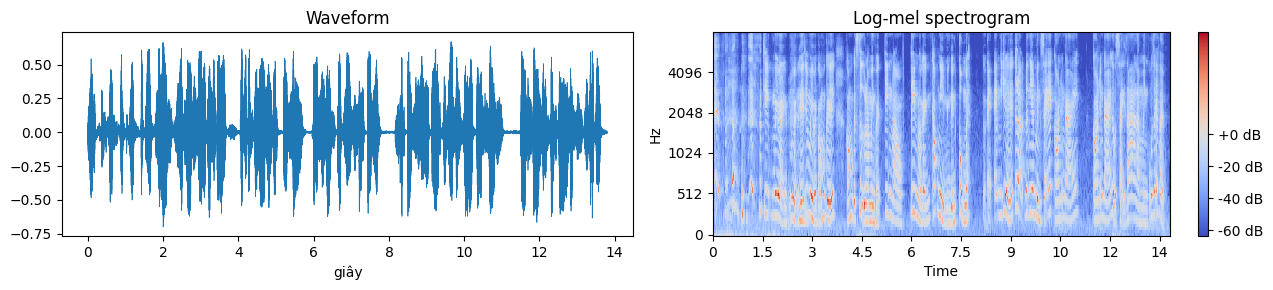


Mẫu 8/10
Nguồn:      Mai_Vo_Brand_Reputation_Lead_tai_Google_HOMECOMING_EP03.mp4
Thời lượng: 10.30s (báo cáo)
Transcript: A LOT MY FRIENDS WARREN BEA TAC AARS BEACOMINY SUN JOURNAL YES MEN AUTO WORK AND STY OF B HE


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


(…)ad_tai_Google_HOMECOMING_EP03_seg057.wav:   0%|          | 0.00/330k [00:00<?, ?B/s]

Thời lượng thực tế: 10.30s, sample rate: 16000 Hz


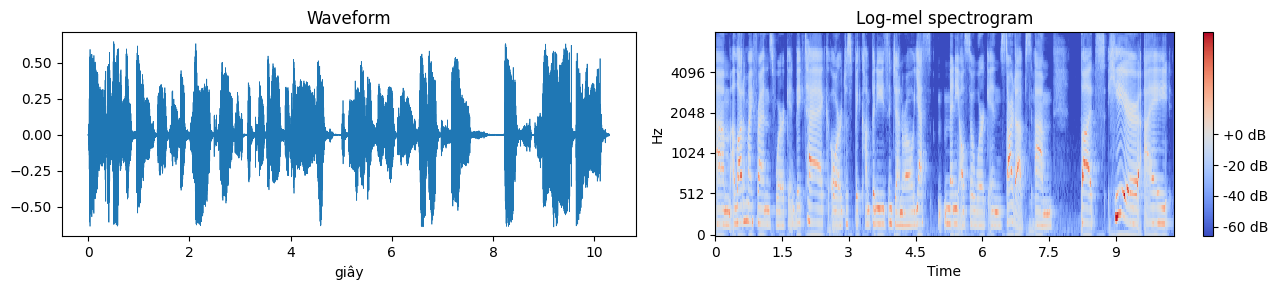


Mẫu 9/10
Nguồn:      Building_innovation_culture_by_investing_in_people_-_Sai_Ponugoti_General_Director_PG_VN_VI_S3E4.mp4
Thời lượng: 12.70s (báo cáo)
Transcript: FORBES TO VÀ DISNEY HAP ORLE FIFT BEAR MIST DEL PUNT ARTHUR IN CLODING US SINGAPORE AUSTRALIA INDONESIA


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


(…)eneral_Director_PG_VN_VI_S3E4_seg108.wav:   0%|          | 0.00/406k [00:00<?, ?B/s]

Thời lượng thực tế: 12.70s, sample rate: 16000 Hz


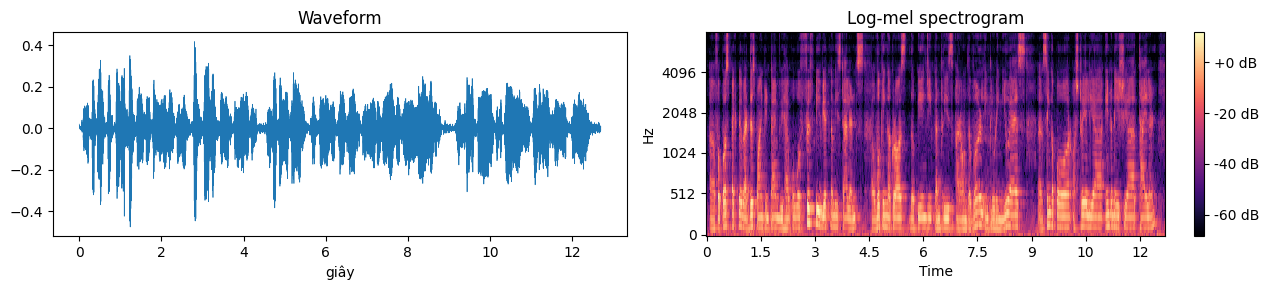


Mẫu 10/10
Nguồn:      Ai_roi_cung_se_co_cho_cua_rieng_minh_-_Ca_si_My_Linh_HaveASip_164.mp4
Thời lượng: 11.30s (báo cáo)
Transcript: EM CÓ THỂ TƯỞNG TƯỢNG MỘT NGÀY XOAY XOAY MẤY LẦN THÌ BỐ AI MÀ CHỊU ĐƯỢC CŨNG KHÔNG THỂ NÀO MÀ CHỊU ĐƯỢC XONG RỒI CÓ LÚC CHỊ BẢO LÀ ÔI EM XIN LỖI ANH Ý EM CẢM THẤY THƯƠNG ANH LẮM Ý BỞI VÌ LÀ


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


(…)_-_Ca_si_My_Linh_HaveASip_164_seg212.wav:   0%|          | 0.00/362k [00:00<?, ?B/s]

Thời lượng thực tế: 11.30s, sample rate: 16000 Hz


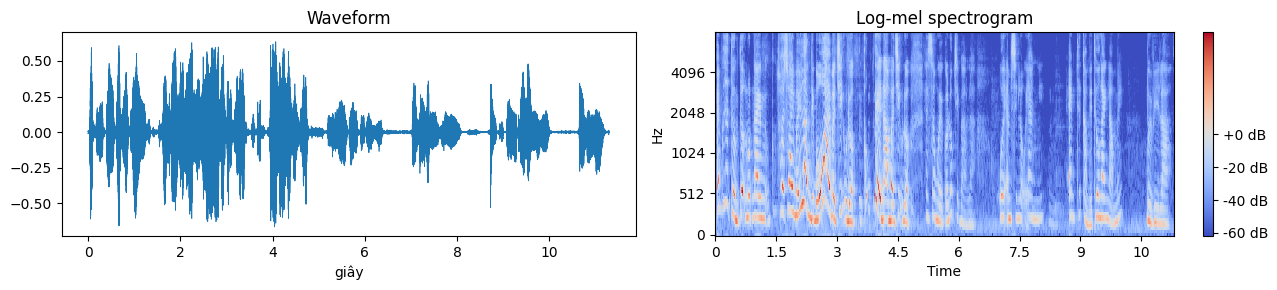

In [7]:
for i, item in enumerate(samples):
    print(f"\n{'=' * 80}\nMẫu {i + 1}/{len(samples)}")
    print(f"Nguồn:      {item['source']}")
    print(f"Thời lượng: {item['duration']:.2f}s (báo cáo)")
    print(f"Transcript: {item['text']}")

    arr, sr = fetch_audio(item["audio"])
    print(f"Thời lượng thực tế: {len(arr) / sr:.2f}s, sample rate: {sr} Hz")

    mel = librosa.feature.melspectrogram(y=arr.astype(np.float32), sr=sr, n_mels=80, hop_length=160, n_fft=400)
    log_mel = librosa.power_to_db(mel)

    fig, axes = plt.subplots(1, 2, figsize=(13, 3))
    t = np.linspace(0, len(arr) / sr, len(arr))
    axes[0].plot(t, arr, linewidth=0.5)
    axes[0].set_title("Waveform")
    axes[0].set_xlabel("giây")

    img = librosa.display.specshow(log_mel, sr=sr, hop_length=160, x_axis="time", y_axis="mel", ax=axes[1])
    axes[1].set_title("Log-mel spectrogram")
    fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
    plt.tight_layout()
    plt.show()

    display(Audio(arr, rate=sr))

## 5. (Khah) Xem trước các mẫu trong clean-test manifest

Đây chính là 250 mẫu đã lấy ngẫu nhiên (seed=42) từ tập `validation` để
hiệu đính thủ công (xem `data/processed/clean_test_manifest.json`, tạo bởi
`src/data/survey.py`). Dùng lại đúng cell dưới đây khi bắt đầu công việc
nghe & sửa transcript — chỉ cần đổi `PREVIEW_N` để xem nhiều/ít hơn.

In [ ]:
PREVIEW_N = 3

manifest_path = Path("data/processed/clean_test_manifest.json")
if manifest_path.exists():
    with open(manifest_path, encoding="utf-8") as f:
        manifest = json.load(f)
    print(f"Manifest: {manifest['n']} mẫu, split={manifest['split']}, seed={manifest['seed']}")

    val_ds = load_dataset(HF_DATASET_ID, split="validation", streaming=False)
    rng = random.Random(SEED)
    preview_entries = rng.sample(manifest["samples"], min(PREVIEW_N, len(manifest["samples"])))

    for entry in preview_entries:
        item = val_ds[entry["index"]]
        print(f"\n[index={entry['index']}] {entry['source']} ({entry['duration_s']:.1f}s)")
        print(f"Pseudo-label: {entry['pseudo_label']}")
        arr, sr = fetch_audio(item["audio"])
        display(Audio(arr, rate=sr))
else:
    print("Chưa có data/processed/clean_test_manifest.json — chạy `python -m src.data.survey` trước.")